**生成式AI的使用**：就本次作业而言，生成式AI的使用同样受关于协作的政策约束。与其他合作者一样，每个学生必须独立于（与AI）交互的输出写下解答，并且在提交的作业中应包含说明协作性质的附注。使用生成式AI工具来实质性地完成作业的大部分内容不符合本次作业的精神，这一行为将违反[荣誉守则](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。

**学生声明（必须填写）**

**SUNet id:**  
_你的 SUNet id_

**你是否使用了生成式AI工具（比如 ChatGPT, Copilot 等）？**  
- [ ] 否  
- [ ] 是（请在下方说明）

**如果是，请说明你是如何使用生成式AI的，以及用于作业的哪些部分：**  
_你的回答_

**确认所有提交的工作反映了你自己的理解，并且你没有依赖AI完成作业的实质性大部分内容：**  
- [ ] 我确认

In [1]:
# 将你的 Google Drive 挂载到 Colab 虚拟机上。
#from google.colab import drive
#drive.mount('/content/drive')

# TODO: 输入你在 Drive 中保存解压后作业文件夹的文件夹名称，
# 例如 'cs231n/assignments/assignment2/'
#FOLDERNAME = 'cs231n/assignments/assignment2/'
#assert FOLDERNAME is not None, "[!] 输入文件夹名称。"

# 现在我们已经挂载了你的 Drive，这确保了
# Colab 虚拟机的 Python 解释器能够从中加载 python 文件。
#import sys
#sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# 如果你的 Drive 中尚未存在 CIFAR-10 数据集，
# 以下代码会将其下载到你的 Drive 中。
#%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
#!bash get_datasets.sh
#%cd /content/drive/My\ Drive/$FOLDERNAME

# 批量归一化 (Batch Normalization)
让深度网络更容易训练的一种方法是使用更复杂的优化程序，如 SGD+momentum、RMSProp 或 Adam。另一种策略是改变网络的架构以使其更容易训练。沿着这个思路，[1] 在2015年提出了批量归一化的想法。

要理解批量归一化的目标，首先要认识到，机器学习方法在使用含不相关特征、零均值和单位方差的数据输入时往往表现更好。在训练神经网络时，我们可以在将数据输入网络之前对数据进行预处理，以显式地对其特征进行去相关。这将确保网络的第一层看到符合良好分布的数据。然而，即使我们对输入数据进行了预处理，网络更深层的激活很可能不再是不相关的，也不再具有零均值或单位方差，因为它们是网络前面层的输出。更糟糕的是，在训练过程中，随着每一层权重的更新，网络每一层特征的分布都会发生偏移。

[1] 的作者假设深度神经网络内部特征分布的偏移可能会使训练深度网络变得更加困难。为了克服这个问题，他们建议在网络中插入标准化批次的层。在训练时，这样的层使用数据的微批次 (minibatch) 来估计每个特征的均值和标准差。然后，这些估计的均值和标准差被用来对微批次的特征进行中心化和标准化。在训练期间会保留这些均值和标准差的运行平均值 (running average)，而在测试时，这些运行平均值被用来对特征进行中心化和标准化。

有可能这种归一化策略会降低网络的表征能力，因为对于某些层来说，拥有非零均值或非单位方差的特征有时可能是最优的。为此，批量归一化层为每个特征维度包含了可学习的平移 (shift) 和缩放 (scale) 参数。

[1] [Sergey Ioffe and Christian Szegedy, "Batch Normalization: Accelerating Deep Network Training by Reducing
Internal Covariate Shift", ICML 2015.](https://arxiv.org/abs/1502.03167)

In [2]:
# 设置单元格。
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # 设置绘图的默认大小。
plt.rcParams["font.family"] = "SimHei"  # 强制使用黑体
plt.rcParams["axes.unicode_minus"] = False  # 解决负号 '-' 显示为方块的问题
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

import sys
import types
import importlib

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """返回相对误差。"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

def print_mean_std(x,axis=0):
    print(f"  手段 (means): {x.mean(axis=axis)}")
    print(f"  标准差 (stds):  {x.std(axis=axis)}\n")

In [3]:
# 加载（经过预处理的）CIFAR-10 数据。
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


# 批量归一化：前向传播
在文件 `cs231n/layers.py` 中，在 `batchnorm_forward` 函数里实现批量归一化的前向传播。完成后，运行以下代码以测试你的实现。

参考上面 [1] 中的论文可能会有帮助！

In [4]:
from cs231n.layers import *

# 通过检查批量归一化前后特征的均值和方差
# 来检查训练时的前向传播

# 模拟一个两层网络的前向传播。
np.random.seed(231)
N, D1, D2, D3 = 200, 50, 60, 3
X = np.random.randn(N, D1)
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)
a = np.maximum(0, X.dot(W1)).dot(W2)

print('批量归一化前 (Before batch normalization):')
print_mean_std(a,axis=0)

gamma = np.ones((D3,))
beta = np.zeros((D3,))

# 均值应接近0，标准差应接近1。
print('批量归一化后 (After batch normalization (gamma=1, beta=0))')
a_norm, _ = batchnorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=0)

gamma = np.asarray([1.0, 2.0, 3.0])
beta = np.asarray([11.0, 12.0, 13.0])

# 现在均值应接近 beta，标准差应接近 gamma。
print('批量归一化后 (After batch normalization (gamma=', gamma, ', beta=', beta, '))')
a_norm, _ = batchnorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=0)

批量归一化前 (Before batch normalization):
  手段 (means): [ -2.3814598  -13.18038246   1.91780462]
  标准差 (stds):  [27.18502186 34.21455511 37.68611762]

批量归一化后 (After batch normalization (gamma=1, beta=0))
  手段 (means): [5.32907052e-17 7.04991621e-17 1.85962357e-17]
  标准差 (stds):  [0.99999999 1.         1.        ]

批量归一化后 (After batch normalization (gamma= [1. 2. 3.] , beta= [11. 12. 13.] ))
  手段 (means): [11. 12. 13.]
  标准差 (stds):  [0.99999999 1.99999999 2.99999999]



In [5]:
# 验证测试时的前向传播，通过多次运行训练时的前向传播
# 来预热（计算）运行平均值，然后
# 在执行测试时前向传播后检查激活的均值和方差。

np.random.seed(231)
N, D1, D2, D3 = 200, 50, 60, 3
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)

bn_param = {'mode': 'train'}
gamma = np.ones(D3)
beta = np.zeros(D3)

for t in range(50):
  X = np.random.randn(N, D1)
  a = np.maximum(0, X.dot(W1)).dot(W2)
  batchnorm_forward(a, gamma, beta, bn_param)

bn_param['mode'] = 'test'
X = np.random.randn(N, D1)
a = np.maximum(0, X.dot(W1)).dot(W2)
a_norm, _ = batchnorm_forward(a, gamma, beta, bn_param)

# 均值应接近零，标准差接近一，但相比于
# 训练时的前向传播噪音会更大一点。
print('批量归一化后 (测试时 After batch normalization (test-time)):')
print_mean_std(a_norm,axis=0)

批量归一化后 (测试时 After batch normalization (test-time)):
  手段 (means): [-0.03927354 -0.04349152 -0.10452688]
  标准差 (stds):  [1.01531428 1.01238373 0.97819988]



# 批量归一化：反向传播
现在在 `batchnorm_backward` 函数中实现批量归一化的反向传播。

为了推导出反向传播，你应该写出批量归一化的计算图，并通过每个中间节点进行反向传播。一些中间节点可能有多个传出分支；确保在反向传播中跨这些分支求和梯度。参考上面链接在 [1] 中的论文可能会有帮助！

一旦你完成了，运行以下代码从数值上检查你的反向传播。

_提示：[这个资源](https://www.adityaagrawal.net/blog/deep_learning/bprop_batch_norm)解释了如何从论文中推导梯度的过程，非常有用。_

In [6]:
# 梯度检查批量归一化 (batchnorm) 的反向传播。
np.random.seed(231)
N, D = 4, 5
x = 5 * np.random.randn(N, D) + 12
gamma = np.random.randn(D)
beta = np.random.randn(D)
dout = np.random.randn(N, D)

bn_param = {'mode': 'train'}
fx = lambda x: batchnorm_forward(x, gamma, beta, bn_param)[0]
fg = lambda a: batchnorm_forward(x, a, beta, bn_param)[0]
fb = lambda b: batchnorm_forward(x, gamma, b, bn_param)[0]

dx_num = eval_numerical_gradient_array(fx, x, dout)
da_num = eval_numerical_gradient_array(fg, gamma.copy(), dout)
db_num = eval_numerical_gradient_array(fb, beta.copy(), dout)

_, cache = batchnorm_forward(x, gamma, beta, bn_param)
dx, dgamma, dbeta = batchnorm_backward(dout, cache)

# 你应该期待看到相对误差在 1e-13 和 1e-8 之间。
print('dx error: ', rel_error(dx_num, dx))
print('dgamma error: ', rel_error(da_num, dgamma))
print('dbeta error: ', rel_error(db_num, dbeta))

dx error:  1.7029227094228273e-09
dgamma error:  7.420414216247087e-13
dbeta error:  2.8795057655839487e-12


# 批量归一化：另一种反向传播实现
在课上，我们讨论了 sigmoid 反向传播的两种不同实现方式。一种策略是写出由简单操作组成的计算图通过所有中间值进行反向传播。另一种策略是在纸上算出导数。例如，你可以通过在纸上简化梯度来推导出 sigmoid 函数非常简单的反向传播公式。

令人惊讶的是，你同样可以为批量归一化的反向传播做一次类似的推导简化！

在前向传播中，给定一组输入 $X=\begin{bmatrix}x_1\\x_2\\...\\x_N\end{bmatrix}$，

我们首先计算均值 $\mu$ 和方差 $v$。
有了算好的 $\mu$ 和 $v$，我们可以计算标准差 $\sigma$ 和标准化归一化的数据 $Y$。
下面的等式和图示描述了这个计算（$y_i$ 是向量 $Y$ 的第 i 个元素）。

\begin{align}
& \mu=\frac{1}{N}\sum_{k=1}^N x_k  &  v=\frac{1}{N}\sum_{k=1}^N (x_k-\mu)^2 \\
& \sigma=\sqrt{v+\epsilon}         &  y_i=\frac{x_i-\mu}{\sigma}
\end{align}

<img src="https://raw.githubusercontent.com/cs231n/cs231n.github.io/master/assets/a2/batchnorm_graph.png">

在反向传播期间，我们问题的核心点是：在给定从上游接收到的梯度 $\frac{\partial L}{\partial Y}$ 时，去计算 $\frac{\partial L}{\partial X}$。为此，回顾微积分里的链式法则有 $\frac{\partial L}{\partial X} = \frac{\partial L}{\partial Y} \cdot \frac{\partial Y}{\partial X}$。

未知/最困难的部分是 $\frac{\partial Y}{\partial X}$。我们可以这样去求：首先一步步得出我们的局部梯度 
$\frac{\partial v}{\partial X}$，$\frac{\partial \mu}{\partial X}$，
$\frac{\partial \sigma}{\partial v}$，
$\frac{\partial Y}{\partial \sigma}$，和 $\frac{\partial Y}{\partial \mu}$，
然后使用链式法则将这些梯度（以向量的形式表现！）适当地组合起来，以算出 $\frac{\partial Y}{\partial X}$。

如果直接对包含矩阵乘法的 $X$ 和 $Y$ 进行梯度推理有困难，试着从单个元素 $x_i$ 和 $y_i$ 的角度先推导：在那种情况下，你需要依靠链式法则先算出中间变量 $\frac{\partial \mu}{\partial x_i}, \frac{\partial v}{\partial x_i}, \frac{\partial \sigma}{\partial x_i}$，然后把这些组合起来计算出最终对于 $\frac{\partial L}{\partial x_i}$ 的推导式。

为了便于实现，你应该确保每个中间变量的梯度推导尽可能的极简。

完成这些后，在 `batchnorm_backward_alt` 函数中编写这套化简过的批量归一化反向图，并通过运行以下代码比较这两种实现。两种实现得出的结果应该是几乎同等的，但替代方法的实现应该稍微快那么一点。

_提示：https://cs.stanford.edu/people/jcjohns/batchnorm.pdf。注意 $\gamma$ 应该纳入到这个最终推导中。_

_请注意该 pdf 中的等式 (8) 应该是：_
$$\frac{1}{\sigma} \frac{\partial}{\partial x_i} (x_j - \mu)
- \frac{1}{\sigma^2} \frac{\partial \sigma}{\partial x_i} (x_j - \mu)$$

In [7]:
np.random.seed(231)
N, D = 100, 500
x = 5 * np.random.randn(N, D) + 12
gamma = np.random.randn(D)
beta = np.random.randn(D)
dout = np.random.randn(N, D)

bn_param = {'mode': 'train'}
out, cache = batchnorm_forward(x, gamma, beta, bn_param)

t1 = time.time()
dx1, dgamma1, dbeta1 = batchnorm_backward(dout, cache)
t2 = time.time()
dx2, dgamma2, dbeta2 = batchnorm_backward_alt(dout, cache)
t3 = time.time()

print('dx 差异 (dx difference): ', rel_error(dx1, dx2))
print('dgamma 差异 (dgamma difference): ', rel_error(dgamma1, dgamma2))
print('dbeta 差异 (dbeta difference): ', rel_error(dbeta1, dbeta2))
print('加速 (speedup): %.2fx' % ((t2 - t1) / (t3 - t2)))

dx 差异 (dx difference):  1.7718020381683009e-12
dgamma 差异 (dgamma difference):  0.0
dbeta 差异 (dbeta difference):  0.0
加速 (speedup): 3.15x


# 带有批量归一化的全连接网络
现在你已经实现了一个可以运行的批量归一化了，请回到文件 `cs231n/classifiers/fc_net.py` 中的 `FullyConnectedNet`。回顾你在作业 1 中实现了网络的初始化、前向传播和反向传播。把那个实现复制到这里，并对其进行修改以加入批量归一化。

具体而言，当在构造函数中设置标志 `normalization` 为 `"batchnorm"` 时，你应该在每个 ReLU 非线性激活操作前面插入一个批量归一化层。网络最后一层的输出不应该被归一化。完成之后，运行以下代码来对你的实现做梯度检查。

**提示：** 你可能会发现定义一个类似于 `cs231n/layer_utils.py` 中的辅助层是有用的。

In [8]:
from cs231n.classifiers.fc_net import *
from cs231n.gradient_check import *

np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

# 你应该期望 W 的损失在 1e-4~1e-10 之间，
# b 的损失在 1e-08~1e-10 之间，
# beta 和 gammas 的损失在 1e-08~1e-09 之间。
for reg in [0, 3.14]:
  print('带正则检查运行中 (Running check with reg) = ', reg)
  model = FullyConnectedNet([H1, H2], input_dim=D, num_classes=C,
                            reg=reg, weight_scale=5e-2, dtype=np.float64,
                            normalization='batchnorm')

  loss, grads = model.loss(X, y)
  print('初始损失 (Initial loss): ', loss)

  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))
  if reg == 0: print()

带正则检查运行中 (Running check with reg) =  0
初始损失 (Initial loss):  2.2611955101340957
W1 relative error: 1.10e-04
W2 relative error: 5.65e-06
W3 relative error: 4.14e-10
b1 relative error: 2.66e-07
b2 relative error: 4.16e-08
b3 relative error: 1.02e-10
beta1 relative error: 7.33e-09
beta2 relative error: 1.17e-09
gamma1 relative error: 7.47e-09
gamma2 relative error: 3.35e-09

带正则检查运行中 (Running check with reg) =  3.14
初始损失 (Initial loss):  6.996533220108303
W1 relative error: 1.98e-06
W2 relative error: 2.28e-06
W3 relative error: 1.11e-08
b1 relative error: 1.38e-08
b2 relative error: 7.99e-07
b3 relative error: 1.73e-10
beta1 relative error: 6.65e-09
beta2 relative error: 3.48e-09
gamma1 relative error: 6.27e-09
gamma2 relative error: 4.67e-09


# 深度网络的批量归一化
运行以下代码在一个有 1000 个训练样本的子集上，去分别训练带有和不带有批量归一化的一个 6 层网络。

In [9]:
np.random.seed(231)

# 尝试用批量归一化训练一个很深的网络。
hidden_dims = [100, 100, 100, 100, 100]

num_train = 1000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

weight_scale = 2e-2
bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization='batchnorm')
model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=None)

print('含批量归一化的求解器 (Solver with batch norm):')
bn_solver = Solver(bn_model, small_data,
                num_epochs=10, batch_size=50,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True,print_every=20)
bn_solver.train()

print('\n没有批量归一化的求解器 (Solver without batch norm):')
solver = Solver(model, small_data,
                num_epochs=10, batch_size=50,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True, print_every=20)
solver.train()

含批量归一化的求解器 (Solver with batch norm):
(Iteration 1 / 200) loss: 2.340974
(Epoch 0 / 10) train acc: 0.107000; val_acc: 0.115000
(Epoch 1 / 10) train acc: 0.314000; val_acc: 0.267000
(Iteration 21 / 200) loss: 2.039345
(Epoch 2 / 10) train acc: 0.393000; val_acc: 0.286000
(Iteration 41 / 200) loss: 2.045770
(Epoch 3 / 10) train acc: 0.481000; val_acc: 0.322000
(Iteration 61 / 200) loss: 1.772057
(Epoch 4 / 10) train acc: 0.529000; val_acc: 0.315000
(Iteration 81 / 200) loss: 1.238057
(Epoch 5 / 10) train acc: 0.618000; val_acc: 0.329000
(Iteration 101 / 200) loss: 1.366125
(Epoch 6 / 10) train acc: 0.649000; val_acc: 0.311000
(Iteration 121 / 200) loss: 1.129775
(Epoch 7 / 10) train acc: 0.670000; val_acc: 0.304000
(Iteration 141 / 200) loss: 1.215402
(Epoch 8 / 10) train acc: 0.725000; val_acc: 0.326000
(Iteration 161 / 200) loss: 0.807462
(Epoch 9 / 10) train acc: 0.787000; val_acc: 0.344000
(Iteration 181 / 200) loss: 0.960723
(Epoch 10 / 10) train acc: 0.780000; val_acc: 0.328000

没有批

运行以下内容以可视化上面训练出来的两个网络的结果。你会发现，使用批量归一化有助于网络大大地加快收敛速度。

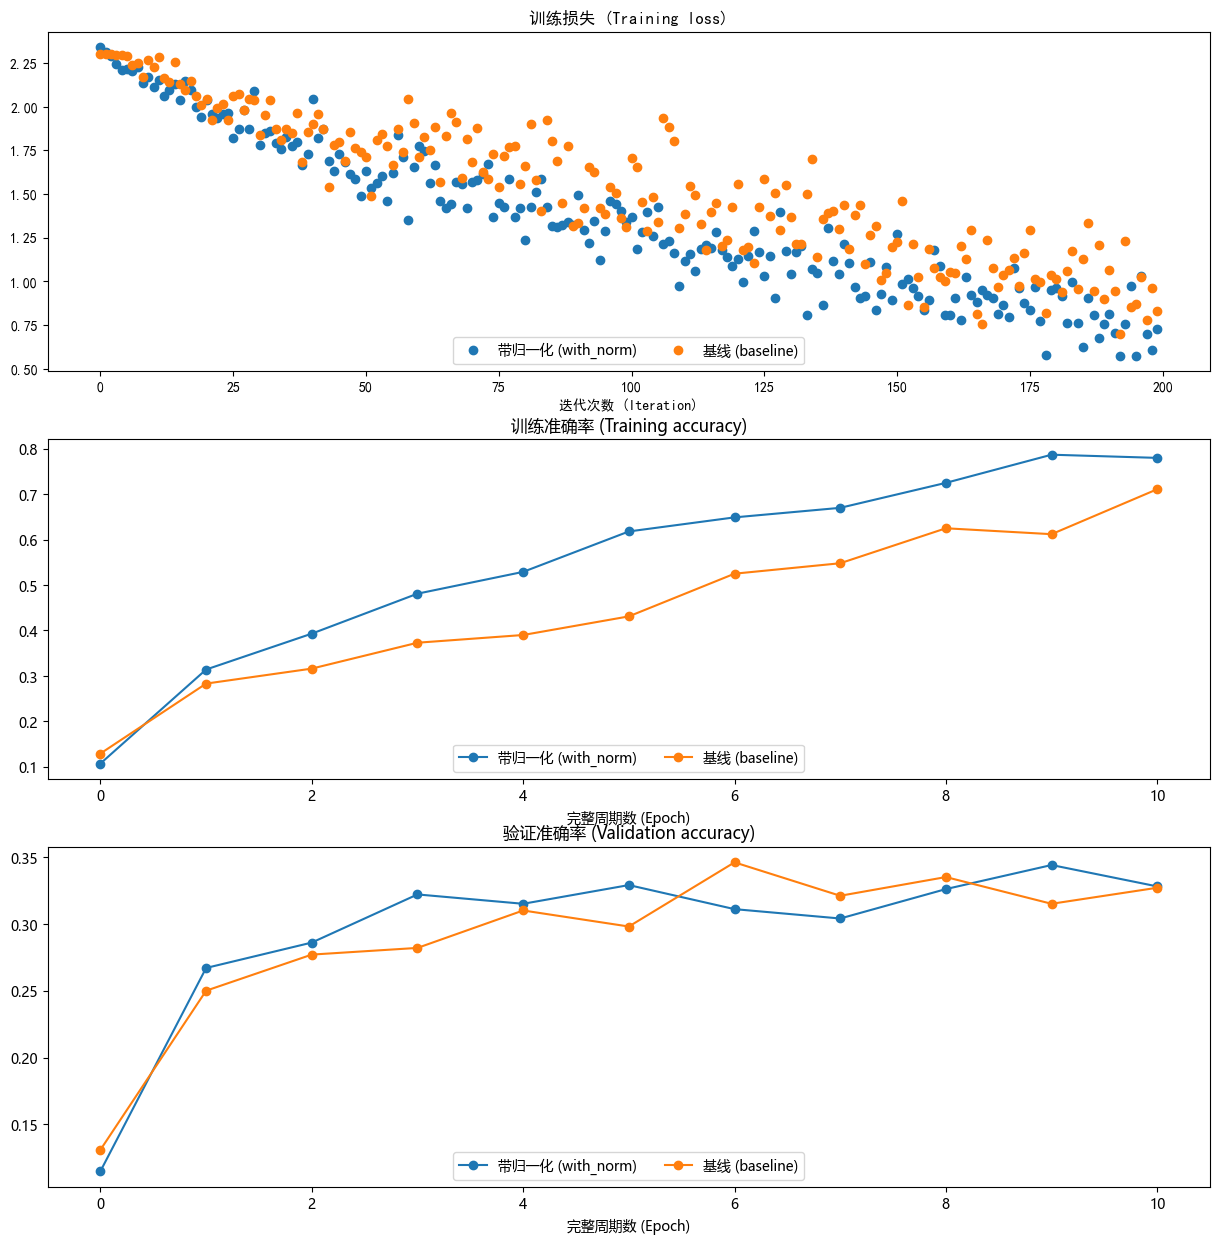

In [10]:
def plot_training_history(title, label, baseline, bn_solvers, plot_fn, bl_marker='.', bn_marker='.', labels=None):
    """用于绘制训练历史的实用功能函数 (utility function for plotting training history)"""
    plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["axes.unicode_minus"] = False
    plt.title(title)
    plt.xlabel(label)
    bn_plots = [plot_fn(bn_solver) for bn_solver in bn_solvers]
    bl_plot = plot_fn(baseline)
    num_bn = len(bn_plots)
    for i in range(num_bn):
        label='带归一化 (with_norm)'
        if labels is not None:
            label += str(labels[i])
        plt.plot(bn_plots[i], bn_marker, label=label)
    label='基线 (baseline)'
    if labels is not None:
        label += str(labels[0])
    plt.plot(bl_plot, bl_marker, label=label)
    plt.legend(loc='lower center', ncol=num_bn+1)


plt.subplot(3, 1, 1)
plot_training_history('训练损失 (Training loss)','迭代次数 (Iteration)', solver, [bn_solver], \
                      lambda x: x.loss_history, bl_marker='o', bn_marker='o')
plt.subplot(3, 1, 2)
plot_training_history('训练准确率 (Training accuracy)','完整周期数 (Epoch)', solver, [bn_solver], \
                      lambda x: x.train_acc_history, bl_marker='-o', bn_marker='-o')
plt.subplot(3, 1, 3)
plot_training_history('验证准确率 (Validation accuracy)','完整周期数 (Epoch)', solver, [bn_solver], \
                      lambda x: x.val_acc_history, bl_marker='-o', bn_marker='-o')

plt.gcf().set_size_inches(15, 15)
plt.show()

# 批量归一化和初始化
现在我们将进行一个小实验来研究批量归一化与权重初始化的相互作用。

第一个单元格将使用不同的权重初始化大小来各自训练一次带有和不带有批量归一化的一个 8 层网络。第二个层（注：指代后方画图的图层或单元格）将绘制随权重初始化大小而变化的训练准确度、验证集准确度和训练损失曲线。

In [11]:
np.random.seed(231)

# 尝试用批量归一化训练一个非常深的网络。
hidden_dims = [50, 50, 50, 50, 50, 50, 50]
num_train = 1000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

bn_solvers_ws = {}
solvers_ws = {}
weight_scales = np.logspace(-4, 0, num=20)
for i, weight_scale in enumerate(weight_scales):
    print('正在运行权重范围 %d / %d (Running weight scale)' % (i + 1, len(weight_scales)))
    bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization='batchnorm')
    model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=None)

    bn_solver = Solver(bn_model, small_data,
                  num_epochs=10, batch_size=50,
                  update_rule='adam',
                  optim_config={
                    'learning_rate': 1e-3,
                  },
                  verbose=False, print_every=200)
    bn_solver.train()
    bn_solvers_ws[weight_scale] = bn_solver

    solver = Solver(model, small_data,
                  num_epochs=10, batch_size=50,
                  update_rule='adam',
                  optim_config={
                    'learning_rate': 1e-3,
                  },
                  verbose=False, print_every=200)
    solver.train()
    solvers_ws[weight_scale] = solver

正在运行权重范围 1 / 20 (Running weight scale)
正在运行权重范围 2 / 20 (Running weight scale)
正在运行权重范围 3 / 20 (Running weight scale)
正在运行权重范围 4 / 20 (Running weight scale)
正在运行权重范围 5 / 20 (Running weight scale)
正在运行权重范围 6 / 20 (Running weight scale)
正在运行权重范围 7 / 20 (Running weight scale)
正在运行权重范围 8 / 20 (Running weight scale)
正在运行权重范围 9 / 20 (Running weight scale)
正在运行权重范围 10 / 20 (Running weight scale)
正在运行权重范围 11 / 20 (Running weight scale)
正在运行权重范围 12 / 20 (Running weight scale)
正在运行权重范围 13 / 20 (Running weight scale)
正在运行权重范围 14 / 20 (Running weight scale)
正在运行权重范围 15 / 20 (Running weight scale)
正在运行权重范围 16 / 20 (Running weight scale)


d:\Python\west2AI\LYFshota.me\cs231n-Assignment 2-25\cs231n\layers.py:155: RuntimeWarning: divide by zero encountered in log
  correct_logprobs = -np.log(probs[range(N), y])


正在运行权重范围 17 / 20 (Running weight scale)
正在运行权重范围 18 / 20 (Running weight scale)
正在运行权重范围 19 / 20 (Running weight scale)
正在运行权重范围 20 / 20 (Running weight scale)


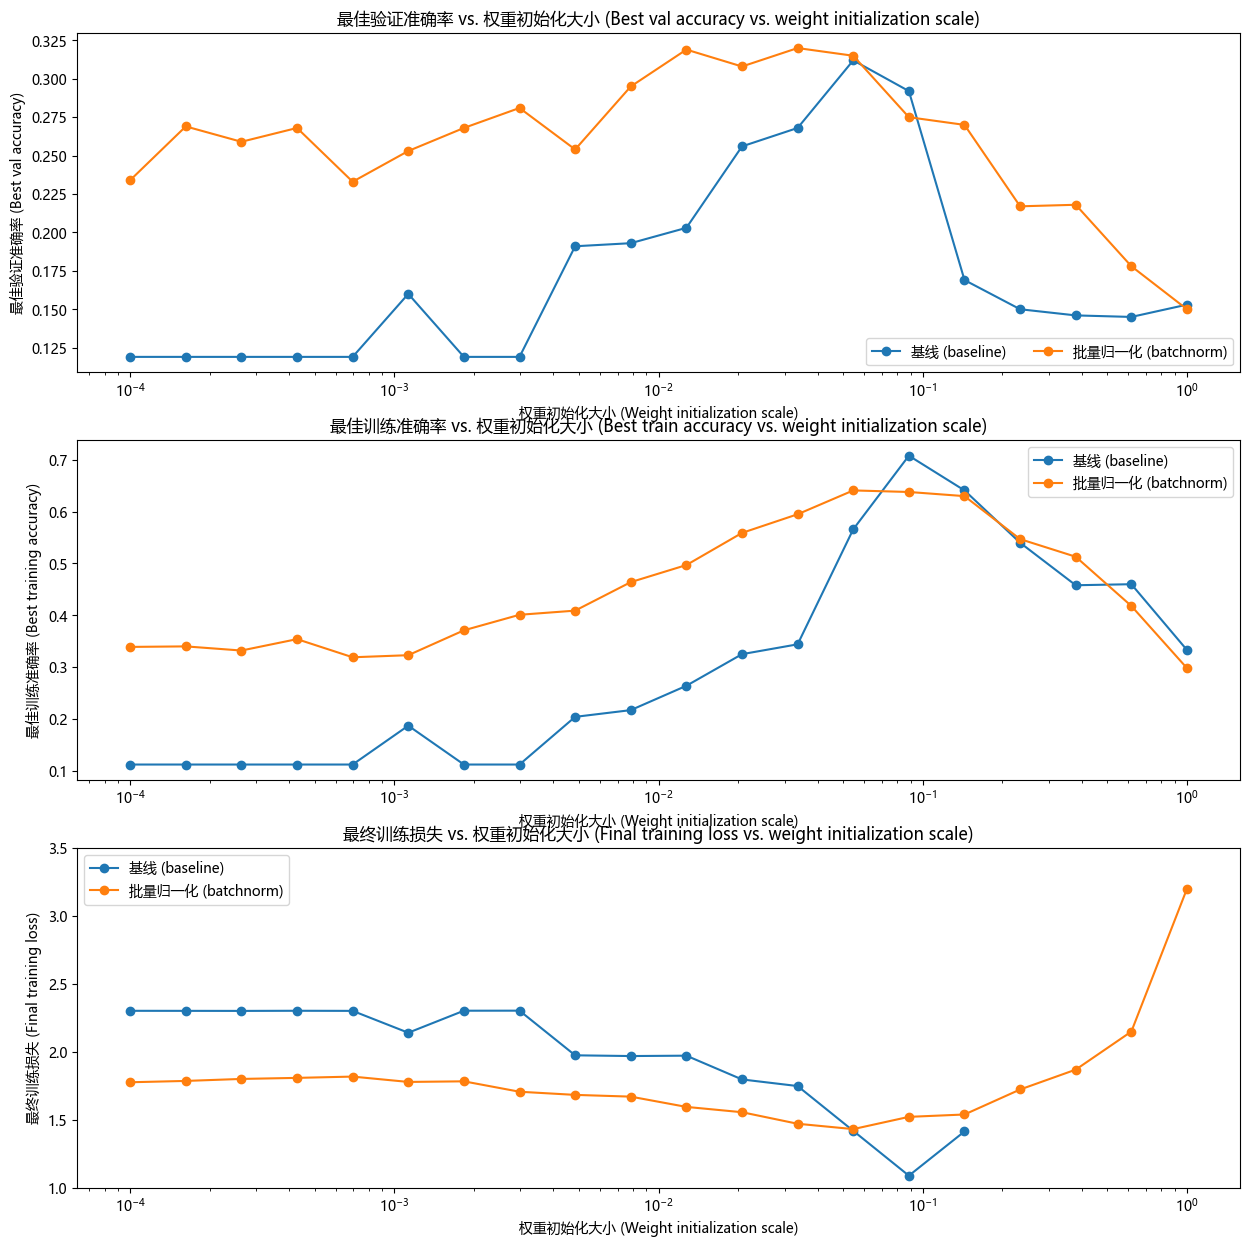

In [12]:
# 绘制权重缩放实验的结果
best_train_accs, bn_best_train_accs = [], []
best_val_accs, bn_best_val_accs = [], []
final_train_loss, bn_final_train_loss = [], []

for ws in weight_scales:
  best_train_accs.append(max(solvers_ws[ws].train_acc_history))
  bn_best_train_accs.append(max(bn_solvers_ws[ws].train_acc_history))

  best_val_accs.append(max(solvers_ws[ws].val_acc_history))
  bn_best_val_accs.append(max(bn_solvers_ws[ws].val_acc_history))

  final_train_loss.append(np.mean(solvers_ws[ws].loss_history[-100:]))
  bn_final_train_loss.append(np.mean(bn_solvers_ws[ws].loss_history[-100:]))

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False
plt.subplot(3, 1, 1)
plt.title('最佳验证准确率 vs. 权重初始化大小 (Best val accuracy vs. weight initialization scale)')
plt.xlabel('权重初始化大小 (Weight initialization scale)')
plt.ylabel('最佳验证准确率 (Best val accuracy)')
plt.semilogx(weight_scales, best_val_accs, '-o', label='基线 (baseline)')
plt.semilogx(weight_scales, bn_best_val_accs, '-o', label='批量归一化 (batchnorm)')
plt.legend(ncol=2, loc='lower right')

plt.subplot(3, 1, 2)
plt.title('最佳训练准确率 vs. 权重初始化大小 (Best train accuracy vs. weight initialization scale)')
plt.xlabel('权重初始化大小 (Weight initialization scale)')
plt.ylabel('最佳训练准确率 (Best training accuracy)')
plt.semilogx(weight_scales, best_train_accs, '-o', label='基线 (baseline)')
plt.semilogx(weight_scales, bn_best_train_accs, '-o', label='批量归一化 (batchnorm)')
plt.legend()

plt.subplot(3, 1, 3)
plt.title('最终训练损失 vs. 权重初始化大小 (Final training loss vs. weight initialization scale)')
plt.xlabel('权重初始化大小 (Weight initialization scale)')
plt.ylabel('最终训练损失 (Final training loss)')
plt.semilogx(weight_scales, final_train_loss, '-o', label='基线 (baseline)')
plt.semilogx(weight_scales, bn_final_train_loss, '-o', label='批量归一化 (batchnorm)')
plt.legend()
plt.gca().set_ylim(1.0, 3.5)

plt.gcf().set_size_inches(15, 15)
plt.show()

## 内联问题 1 (Inline Question 1)：
描述这个实验的结果。权重初始化大小是如何不同地影响带有/不带有批量归一化的模型的，又是为什么呢？

## 答案：
结果：在没有BN的时候，权重太小会导致到后面的层梯度消失，权重太大又会导致梯度爆炸，只有在特定范围才能勉强学习。如果是带有BN的话，不管前面传来的信号太大还是太小，都会被强行拉回到标准范围，从而使得网络对权重初始化的大小不敏感，让训练更稳定。



# 批量归一化和批次大小 (Batch Size)
现在我们将进行一个小实验来研究批量归一化与批次大小相互作用的关系。

第一个单元格将分别使用不同的批次大小去训练有/没有批量归一化的一个 6 层网络。第二个层将绘制随着时间推移的训练验证集准确度和验证准确度的一张曲线表图。

In [13]:
def run_batchsize_experiments(normalization_mode):
    np.random.seed(231)

    # 尝试用批量归一化训练一个非常深的网络。
    hidden_dims = [100, 100, 100, 100, 100]
    num_train = 1000
    small_data = {
      'X_train': data['X_train'][:num_train],
      'y_train': data['y_train'][:num_train],
      'X_val': data['X_val'],
      'y_val': data['y_val'],
    }
    n_epochs=10
    weight_scale = 2e-2
    batch_sizes = [5,10,50]
    lr = 10**(-3.5)
    solver_bsize = batch_sizes[0]

    print('没有归一化 (No normalization): 批次大小 (batch size) = ',solver_bsize)
    model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=None)
    solver = Solver(model, small_data,
                    num_epochs=n_epochs, batch_size=solver_bsize,
                    update_rule='adam',
                    optim_config={
                      'learning_rate': lr,
                    },
                    verbose=False)
    solver.train()

    bn_solvers = []
    for i in range(len(batch_sizes)):
        b_size=batch_sizes[i]
        print('包含归一化 (Normalization): 批次大小 (batch size) = ',b_size)
        bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=normalization_mode)
        bn_solver = Solver(bn_model, small_data,
                        num_epochs=n_epochs, batch_size=b_size,
                        update_rule='adam',
                        optim_config={
                          'learning_rate': lr,
                        },
                        verbose=False)
        bn_solver.train()
        bn_solvers.append(bn_solver)

    return bn_solvers, solver, batch_sizes

batch_sizes = [5,10,50]
bn_solvers_bsize, solver_bsize, batch_sizes = run_batchsize_experiments('batchnorm')

没有归一化 (No normalization): 批次大小 (batch size) =  5
包含归一化 (Normalization): 批次大小 (batch size) =  5
包含归一化 (Normalization): 批次大小 (batch size) =  10
包含归一化 (Normalization): 批次大小 (batch size) =  50


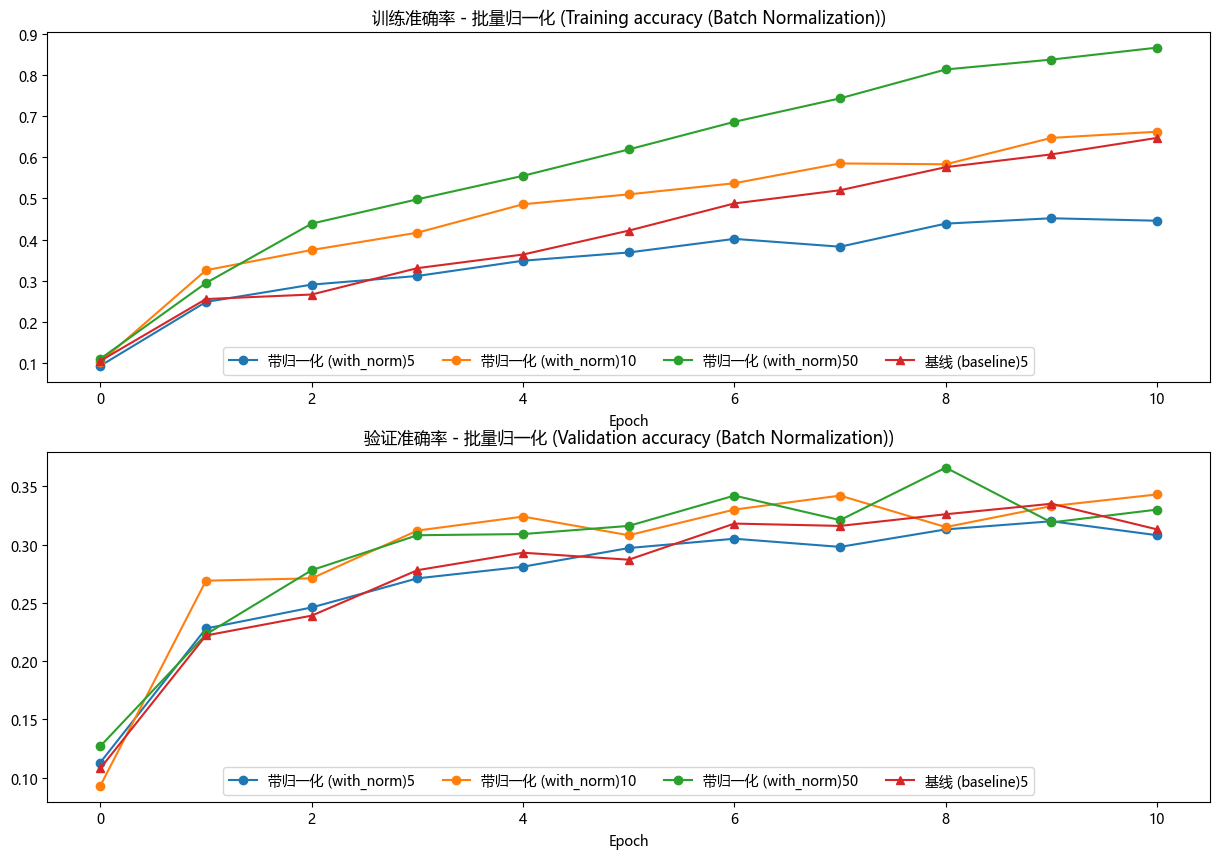

In [14]:
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False
plt.subplot(2, 1, 1)
plot_training_history('训练准确率 - 批量归一化 (Training accuracy (Batch Normalization))','Epoch', solver_bsize, bn_solvers_bsize, \
                      lambda x: x.train_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)
plt.subplot(2, 1, 2)
plot_training_history('验证准确率 - 批量归一化 (Validation accuracy (Batch Normalization))','Epoch', solver_bsize, bn_solvers_bsize, \
                      lambda x: x.val_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)

plt.gcf().set_size_inches(15, 10)
plt.show()

## 内联问题 2 (Inline Question 2)：
描述这个实验的结果。这暗示了批量归一化和批次大小之间有何关系？为什么会观察到这种关系？

## 答案：
使用了BN的模型，在批次大小很小的时候，训练准确率和验证准确率都较低，且波动较大，当批次大小增大的时候，模型的各项指标都有很大提升。暗示了批量归一化的性能高度依赖于批次的大小，因为批量归一化在训练的时候，使用当前批次里面的样本数据来算均值和方差，如果太小的话，算出来的数据随机性太大，不能很好的代表整个样本的分部。



# 层归一化 (Layer Normalization)
批量归一化已被证明在使网络更容易训练上具有有效性，但是它对批次大小表现出的依赖让它在较复杂网络上失去了实用的价值（这类复杂网络受硬件限制必须限制给入的输入批次大小上限）。

为了减轻这个问题，人们提出了几种对于批量归一化的替代方案；一种这样的技术就是层归一化 (Layer Normalization)[2]。不同于在整个批次上进行归一化，我们在它的全部特征内单独自己做进行归一化。换句话说，在使用层归一化时，每个属于只由单个数据点组成的特征向量，将会被基于其自身那个单数据点所对应的特征向量所有各个项的总和（等等），在其自身上做一个标准化。

[2] [Ba, Jimmy Lei, Jamie Ryan Kiros, and Geoffrey E. Hinton. "Layer Normalization." stat 1050 (2016): 21.](https://arxiv.org/pdf/1607.06450.pdf)

## 内联问题 3 (Inline Question 3)：
以下哪些数据预处理步骤类似于批量归一化，哪些类似于层归一化？

1. 对数据集中的每张图像进行缩放，使一张图像中每一行像素的 RGB 通道加起来为 1。
2. 对数据集中的每张图像进行缩放，使一张图像中所有像素的 RGB 通道加起来为 1。  
3. 从数据集中的每张图像减去数据集的平均图像。
4. 根据给定的阈值，将所有的 RGB 值设置为 0 或 1。

## 答案：
[在此填写你的答案]
3类似批量归一化
2类似层归一化


# 层归一化：实现

现在你将实现层归一化。这一步应该是相对简单的，因为从概念上讲，它的实现与批量归一化的实现几乎相同。但一个重要的区别是，对于层归一化，我们不会跟踪运行矩（即不持续计算运行均值这些），测试阶段与训练阶段相同，也是通过同样方式去直接计算出每一个单个数据点的那各自一套均值与方差。

你需要做的是：

* 在 `cs231n/layers.py` 中，在 `layernorm_forward` 函数里实现层归一化的前向传播。

运行下方的单元格以检查你的结果。
* 在 `cs231n/layers.py` 中，在 `layernorm_backward` 函数里实现层归一化的反向传播。

运行下方的第二个单元格以检查你的结果。
* 调整 `cs231n/classifiers/fc_net.py` 以将层归一化作为其中一个可选添加项加入到 `FullyConnectedNet` 中去。当在构造函数中设置标志 `normalization` 为 `"layernorm"` 时，你应该在每个 ReLU 非线性激活操作前面插入一个对应的层归一化。

运行后方的第三个单元格去运行一个基于上面说的层归一化方式的批次大小实验。

In [15]:
# 通过在层归一化前后检查特征的均值和方差
# 来检查训练时的前向传播。

# 模拟一个两层网络的前向传播。
np.random.seed(231)
N, D1, D2, D3 =4, 50, 60, 3
X = np.random.randn(N, D1)
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)
a = np.maximum(0, X.dot(W1)).dot(W2)

print('层归一化前 (Before layer normalization):')
print_mean_std(a,axis=1)

gamma = np.ones(D3)
beta = np.zeros(D3)

# 均值应接近0，标准差应接近1。
print('层归一化后 (After layer normalization (gamma=1, beta=0))')
a_norm, _ = layernorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=1)

gamma = np.asarray([3.0,3.0,3.0])
beta = np.asarray([5.0,5.0,5.0])

# 现在均值应接近 beta，标准差应接近 gamma。
print('层归一化后 (After layer normalization (gamma=', gamma, ', beta=', beta, '))')
a_norm, _ = layernorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=1)

层归一化前 (Before layer normalization):
  手段 (means): [-59.06673243 -47.60782686 -43.31137368 -26.40991744]
  标准差 (stds):  [10.07429373 28.39478981 35.28360729  4.01831507]

层归一化后 (After layer normalization (gamma=1, beta=0))
  手段 (means): [ 4.81096644e-16 -7.40148683e-17  2.22044605e-16 -5.92118946e-16]
  标准差 (stds):  [0.99999995 0.99999999 1.         0.99999969]

层归一化后 (After layer normalization (gamma= [3. 3. 3.] , beta= [5. 5. 5.] ))
  手段 (means): [5. 5. 5. 5.]
  标准差 (stds):  [2.99999985 2.99999998 2.99999999 2.99999907]



In [16]:
# 梯度检查批量归一化(应为层归一化)的反向传播 (Gradient check batchnorm backward pass)。
np.random.seed(231)
N, D = 4, 5
x = 5 * np.random.randn(N, D) + 12
gamma = np.random.randn(D)
beta = np.random.randn(D)
dout = np.random.randn(N, D)

ln_param = {}
fx = lambda x: layernorm_forward(x, gamma, beta, ln_param)[0]
fg = lambda a: layernorm_forward(x, a, beta, ln_param)[0]
fb = lambda b: layernorm_forward(x, gamma, b, ln_param)[0]

dx_num = eval_numerical_gradient_array(fx, x, dout)
da_num = eval_numerical_gradient_array(fg, gamma.copy(), dout)
db_num = eval_numerical_gradient_array(fb, beta.copy(), dout)

_, cache = layernorm_forward(x, gamma, beta, ln_param)
dx, dgamma, dbeta = layernorm_backward(dout, cache)

# 你应该期待看到相对误差界于 1e-12 到 1e-8 之间。
print('dx 误差 (dx error): ', rel_error(dx_num, dx))
print('dgamma 误差 (dgamma error): ', rel_error(da_num, dgamma))
print('dbeta 误差 (dbeta error): ', rel_error(db_num, dbeta))

dx 误差 (dx error):  1.433615657860454e-09
dgamma 误差 (dgamma error):  4.519489546032799e-12
dbeta 误差 (dbeta error):  2.276445013433725e-12


# 层归一化和批次大小 (Layer Normalization and Batch Size)

现在，我们将使用层归一化取代批量归一化来运行之前的批次大小大小探索实验。相比较之前使用批量归一化的那个实验版本，这次你应该能发现在批次大小这块对它运行出的训练历史影响会大大的减弱许多很多！

没有归一化 (No normalization): 批次大小 (batch size) =  5
包含归一化 (Normalization): 批次大小 (batch size) =  5
包含归一化 (Normalization): 批次大小 (batch size) =  10
包含归一化 (Normalization): 批次大小 (batch size) =  50


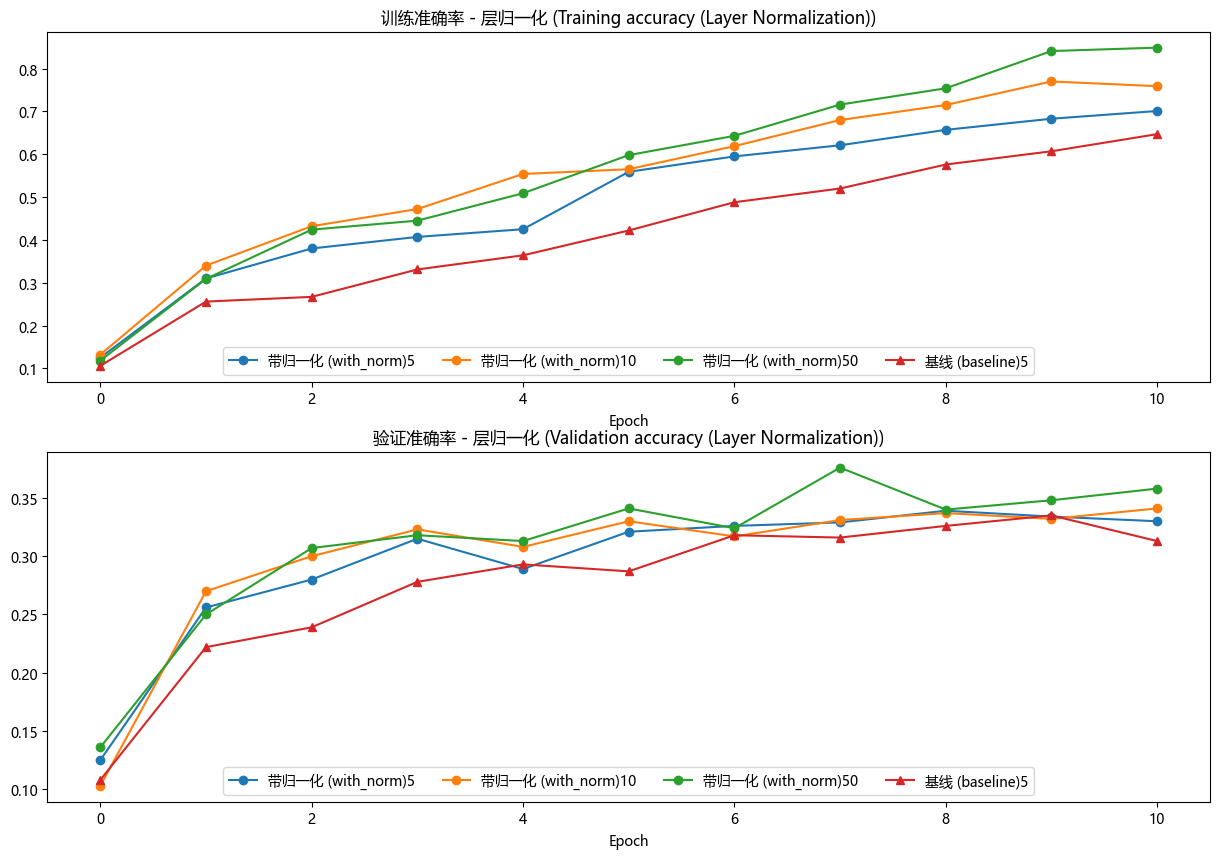

In [17]:
ln_solvers_bsize, solver_bsize, batch_sizes = run_batchsize_experiments('layernorm')

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False
plt.subplot(2, 1, 1)
plot_training_history('训练准确率 - 层归一化 (Training accuracy (Layer Normalization))','Epoch', solver_bsize, ln_solvers_bsize, \
                      lambda x: x.train_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)
plt.subplot(2, 1, 2)
plot_training_history('验证准确率 - 层归一化 (Validation accuracy (Layer Normalization))','Epoch', solver_bsize, ln_solvers_bsize, \
                      lambda x: x.val_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)

plt.gcf().set_size_inches(15, 10)
plt.show()

## 内联问题 4 (Inline Question 4)：
在什么情况下层归一化可能效果不佳，又是为什么？

1. 在一个非常深的网络中使用它
2. 特征维度非常小的情况
3. 具有非常高的一项正则化常数的情况


## 答案：
2. 特征维度非常小的情况，因为层归一化是在每个样本内部的所有特征维度上面计算平均值和方差，如果一个样本里面特征维度非常小的话，计算出来的数据会有很大的随机性。

